# Autoencoder — Best Config: [512 → 256 → 128] → 16

This notebook trains the best-performing autoencoder found in `autoencoder_hyperparameter_comparison.ipynb`.

**Architecture:** `535 → 512 → 256 → 128 → 16 → 128 → 256 → 512 → 535`

**Key difference from `autoencoder.ipynb`:** `all_spectra.csv` is split 80/20.
- The model trains only on the **80% training split**.
- Evaluation uses the **20% held-out normal split concatenated with `ambient_spectra.csv`** as the test set.

This gives a more realistic evaluation: the threshold is still derived from training scores, but
normal samples in the test set were never seen during training.

## 1. Hyperparameters

In [4]:
# ── Best configuration from hyperparameter comparison ────────────────────────

HIDDEN_DIMS          = [512, 256, 128]  # encoder hidden layer sizes (decoder mirrors in reverse)
LATENT_DIM           = 16              # bottleneck dimension
LEARNING_RATE        = 1e-3            # Adam optimizer learning rate
EPOCHS               = 100             # number of training epochs
BATCH_SIZE           = 64             # samples per gradient update
THRESHOLD_PERCENTILE = 95             # percentile of normal training scores used as decision threshold
TEST_SIZE            = 0.20           # fraction of all_spectra held out for testing
RANDOM_STATE         = 42             # reproducibility seed

# ─────────────────────────────────────────────────────────────────────────────

## 2. Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Using device: cpu


## 3. Load Data and Split

`all_spectra.csv` is split 80/20:
- **Train set** — 80% of normal polymer spectra, used exclusively for training.
- **Test set** — 20% of normal polymer spectra + all 55 ambient samples, used for evaluation only.

A random split is used (no stratification) because several polymer classes have only 1 sample,
which is too few for stratified splitting. Since the model trains unsupervised and never uses labels,
class proportionality in the split does not affect training.

In [6]:
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

X_all     = all_spectra[wavelengths].values.astype(np.float32)   # (1215, 535)
y_all     = all_spectra[label_col].values
X_anomaly = ambient_spectra[wavelengths].values.astype(np.float32)  # (55, 535)

# Random 80/20 split — no stratification because some polymer classes have only 1 sample
X_train, X_test_normal = train_test_split(
    X_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Test set = held-out normal samples + all ambient anomalies
X_test = np.concatenate([X_test_normal, X_anomaly], axis=0)
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),  # 0 = normal
    np.ones(len(X_anomaly))        # 1 = anomaly
])

print('── Dataset Split ──────────────────────────────────────────')
print(f'  all_spectra total          : {X_all.shape}')
print(f'  Training set (80%)         : {X_train.shape}')
print(f'  Test normal  (20%)         : {X_test_normal.shape}')
print(f'  Test anomaly (ambient)     : {X_anomaly.shape}')
print(f'  Test set total             : {X_test.shape}')
print('───────────────────────────────────────────────────────────')

── Dataset Split ──────────────────────────────────────────
  all_spectra total          : (1215, 535)
  Training set (80%)         : (972, 535)
  Test normal  (20%)         : (243, 535)
  Test anomaly (ambient)     : (55, 535)
  Test set total             : (298, 535)
───────────────────────────────────────────────────────────


## 4. Define Autoencoder Architecture

Full architecture with default settings:
```
Encoder: 535 → 512 → 256 → 128 → 16
Decoder:  16 → 128 → 256 → 512 → 535
```
ReLU activations between all hidden layers. The decoder output is linear (no activation).

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        encoder_layers = []
        in_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(in_dim, h))
            encoder_layers.append(nn.ReLU())
            in_dim = h
        encoder_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        in_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(in_dim, h))
            decoder_layers.append(nn.ReLU())
            in_dim = h
        decoder_layers.append(nn.Linear(in_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))


input_dim = X_train.shape[1]
model     = Autoencoder(input_dim, HIDDEN_DIMS, LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=535, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=535, bias=True)
  )
)

Total trainable parameters: 881,959


## 5. Train Autoencoder

Trained exclusively on the **80% training split** using MSE loss. No labels or anomaly samples are used.

In [8]:
X_tensor = torch.tensor(X_train, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

train_losses = []
model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)

    epoch_loss /= len(X_train)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1:3d}/{EPOCHS}]  Loss: {epoch_loss:.6f}')

print('\nTraining complete.')

Epoch [ 10/100]  Loss: 0.183501
Epoch [ 20/100]  Loss: 0.129631
Epoch [ 30/100]  Loss: 0.109334
Epoch [ 40/100]  Loss: 0.093233
Epoch [ 50/100]  Loss: 0.079994
Epoch [ 60/100]  Loss: 0.062476
Epoch [ 70/100]  Loss: 0.050802
Epoch [ 80/100]  Loss: 0.040142
Epoch [ 90/100]  Loss: 0.037641
Epoch [100/100]  Loss: 0.028657

Training complete.


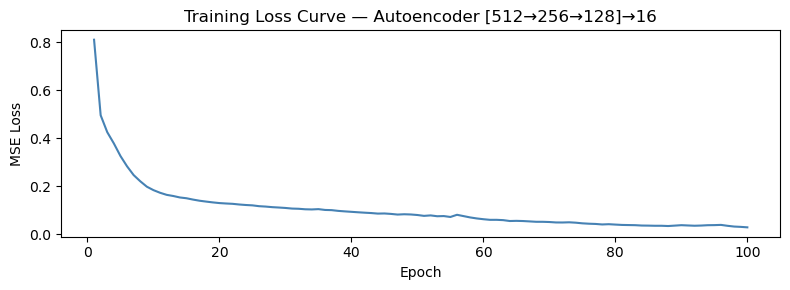

Final training loss: 0.028657


In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, EPOCHS + 1), train_losses, color='steelblue', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Curve — Autoencoder [512→256→128]→16')
plt.tight_layout()
plt.savefig('../figures/autoencoder_best_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final training loss: {train_losses[-1]:.6f}')

## 6. Compute Anomaly Scores

Anomaly score = mean squared reconstruction error per sample:
$$\text{score}(x) = \frac{1}{D} \sum_{i=1}^{D} (x_i - \hat{x}_i)^2$$

Scores are computed for:
- **Training set** — used to derive the decision threshold.
- **Test normal (20% held-out)** — normal samples the model has never seen.
- **Ambient anomalies** — the 55 ambient samples.

In [10]:
model.eval()
with torch.no_grad():
    t_train  = torch.tensor(X_train,       dtype=torch.float32).to(device)
    t_normal = torch.tensor(X_test_normal, dtype=torch.float32).to(device)
    t_amb    = torch.tensor(X_anomaly,     dtype=torch.float32).to(device)

    recon_train  = model(t_train).cpu().numpy()
    recon_normal = model(t_normal).cpu().numpy()
    recon_amb    = model(t_amb).cpu().numpy()

# Per-sample MSE
scores_train  = np.mean((X_train       - recon_train)  ** 2, axis=1)  # (972,)
scores_normal = np.mean((X_test_normal - recon_normal) ** 2, axis=1)  # (243,)
scores_anomaly = np.mean((X_anomaly    - recon_amb)    ** 2, axis=1)  # (55,)

print(f'Train scores   — min: {scores_train.min():.4f}  max: {scores_train.max():.4f}  mean: {scores_train.mean():.4f}')
print(f'Test normal    — min: {scores_normal.min():.4f}  max: {scores_normal.max():.4f}  mean: {scores_normal.mean():.4f}')
print(f'Test anomaly   — min: {scores_anomaly.min():.4f}  max: {scores_anomaly.max():.4f}  mean: {scores_anomaly.mean():.4f}')

Train scores   — min: 0.0048  max: 0.2215  mean: 0.0290
Test normal    — min: 0.0056  max: 1.3276  mean: 0.1568
Test anomaly   — min: 0.0309  max: 1.0914  mean: 0.3667


## 7. Set Decision Threshold

Threshold = `THRESHOLD_PERCENTILE` of **training** reconstruction errors.
Samples in the test set with a score above this are flagged as anomalies.

In [11]:
threshold = np.percentile(scores_train, THRESHOLD_PERCENTILE)

print(f'Threshold (p{THRESHOLD_PERCENTILE} of training scores): {threshold:.6f}')
print(f'Samples with reconstruction error > {threshold:.6f} are flagged as anomalies.')

Threshold (p95 of training scores): 0.088130
Samples with reconstruction error > 0.088130 are flagged as anomalies.


## 8. Anomaly Score Distribution

Histogram of reconstruction errors for the held-out normal test split (blue) and ambient anomalies (orange). The red dashed line marks the decision threshold.

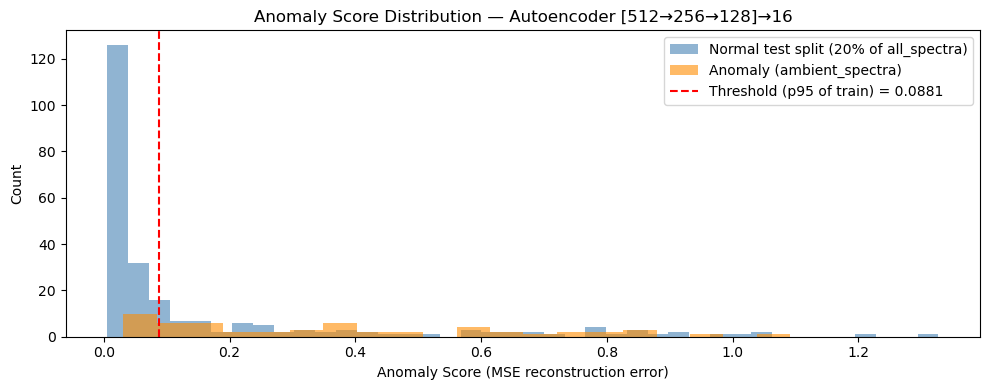

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(scores_normal,  bins=40, alpha=0.6, color='steelblue',  label='Normal test split (20% of all_spectra)')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient_spectra)')
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (p{THRESHOLD_PERCENTILE} of train) = {threshold:.4f}')

ax.set_xlabel('Anomaly Score (MSE reconstruction error)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Score Distribution — Autoencoder [512→256→128]→16')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/autoencoder_best_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluate Performance

Predictions on the test set (20% normal + 55 ambient):
- Label convention: `0` = normal, `1` = anomaly
- Score > threshold → predicted anomaly

In [13]:
# Combine test scores and true labels
all_test_scores = np.concatenate([scores_normal, scores_anomaly])
pred_labels     = (all_test_scores > threshold).astype(int)

roc_auc = roc_auc_score(y_test, all_test_scores)

print(f'ROC-AUC Score : {roc_auc:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, pred_labels, target_names=['Normal', 'Anomaly']))

ROC-AUC Score : 0.8028

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.69      0.80       243
     Anomaly       0.38      0.82      0.51        55

    accuracy                           0.71       298
   macro avg       0.66      0.75      0.66       298
weighted avg       0.84      0.71      0.75       298



## 10. Confusion Matrix

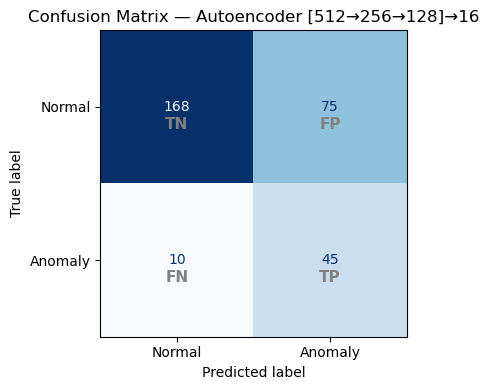

TN=168  FP=75  FN=10  TP=45
Recall   : 0.818
Precision: 0.375


In [14]:
cm   = confusion_matrix(y_test, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Autoencoder [512→256→128]→16')

cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'\n\n{cell_labels[i][j]}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='gray')

plt.tight_layout()
plt.savefig('../figures/autoencoder_best_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Recall   : {tp / (tp + fn):.3f}')
print(f'Precision: {tp / (tp + fp):.3f}')

## 11. ROC Curve

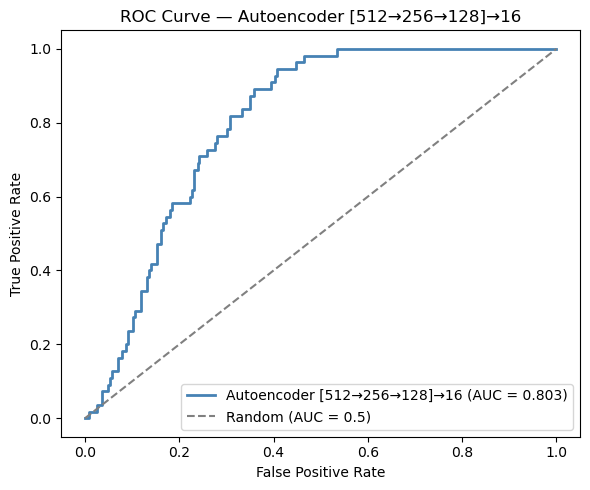

In [15]:
fpr, tpr, _ = roc_curve(y_test, all_test_scores)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Autoencoder [512→256→128]→16 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Autoencoder [512→256→128]→16')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/autoencoder_best_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()